In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [6]:
G = nx.Graph()
G.add_node("NL")
G.add_node("DK")
G.add_node("DE")
G.add_node("BE")

G.add_edge("NL", "DK")
G.add_edge("NL", "DE")
G.add_edge("NL", "BE")
G.add_edge("DE", "BE")
G.add_edge("DE", "DK")

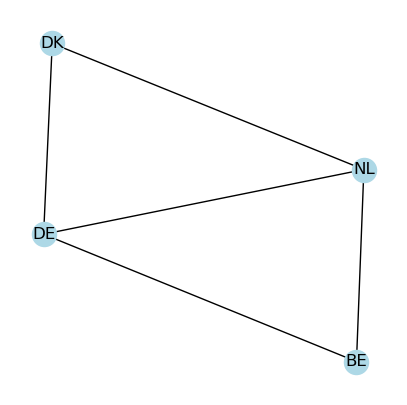

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
nx.draw(G, with_labels=True, ax=ax, node_color="lightblue")

In [8]:
incidence_matrix = nx.incidence_matrix(G, oriented=True, weight=None).todense()
incidence_matrix

array([[-1., -1., -1.,  0.,  0.],
       [ 1.,  0.,  0., -1.,  0.],
       [ 0.,  1.,  0.,  1., -1.],
       [ 0.,  0.,  1.,  0.,  1.]])

In [ ]:
import numpy as np

# -----------------------------
# 1. INCIDENCE MATRIX (K)
# -----------------------------
K = np.array([
    [-1, -1, -1,  0,  0],  # NL
    [ 1,  0,  0, -1,  0],  # DK
    [ 0,  1,  0,  1, -1],  # DE
    [ 0,  0,  1,  0,  1]   # BE
], dtype=float)

print("K =\n", K)


# -----------------------------
# 2. SUSCEPTANCE MATRIX (B)
# -----------------------------
x = 0.1
B = (1/x) * np.eye(K.shape[1])

print("\nB =\n", B)



print("\nK_T =\n", K.T)

# -----------------------------
# 3. LAPLACIAN (L = K B K^T)
# Gives the same result with the two approaches
# -----------------------------

#L = K @ B @ K.T
L =10 * K @ K.T
print("\nL =\n", L)


# -----------------------------
# 4. REDUCED LAPLACIAN (SLACK NODE)
# -----------------------------
# BE is slack → index 3
slack = 3

mask = [i for i in range(L.shape[0]) if i != slack]
L_reduced = L[np.ix_(mask, mask)]

print("\nL_reduced =\n", L_reduced)


# -----------------------------
# 5. INVERSE OF REDUCED LAPLACIAN
# -----------------------------
L_reduced_inv = np.linalg.inv(L_reduced)

print("\nL_reduced_inv =\n", L_reduced_inv)


# -----------------------------
# 6. EXPAND BACK TO FULL L^-1
# -----------------------------
L_inv = np.zeros_like(L)

for i, ii in enumerate(mask):
    for j, jj in enumerate(mask):
        L_inv[ii, jj] = L_reduced_inv[i, j]

print("\nL_inv (with slack node) =\n", L_inv)


# -----------------------------
# 7. PTDF MATRIX
# Gives the same result with the two approaches
# -----------------------------

#PTDF = B @ K.T @ L_inv
PTDF = 10 *K.T @ L_inv

print("\nPTDF =\n", PTDF)


# -----------------------------
# 8. INSERT YOUR NODAL BALANCES HERE
# -----------------------------
# IMPORTANT: must sum to zero
p = np.array([
    862,  # NL
    2681,  # DK
    -4262,  # DE
    719   # BE
])

# -----------------------------
# 9. LINE FLOWS
# -----------------------------
p_l = PTDF @ p

print("\nLine flows p_l =\n", p_l)

K =
 [[-1. -1. -1.  0.  0.]
 [ 1.  0.  0. -1.  0.]
 [ 0.  1.  0.  1. -1.]
 [ 0.  0.  1.  0.  1.]]

B =
 [[10.  0.  0.  0.  0.]
 [ 0. 10.  0.  0.  0.]
 [ 0.  0. 10.  0.  0.]
 [ 0.  0.  0. 10.  0.]
 [ 0.  0.  0.  0. 10.]]

K_T =
 [[-1.  1.  0.  0.]
 [-1.  0.  1.  0.]
 [-1.  0.  0.  1.]
 [ 0. -1.  1.  0.]
 [ 0.  0. -1.  1.]]

L =
 [[ 30. -10. -10. -10.]
 [-10.  20. -10.   0.]
 [-10. -10.  30. -10.]
 [-10.   0. -10.  20.]]

L_reduced =
 [[ 30. -10. -10.]
 [-10.  20. -10.]
 [-10. -10.  30.]]

L_reduced_inv =
 [[0.0625 0.05   0.0375]
 [0.05   0.1    0.05  ]
 [0.0375 0.05   0.0625]]

L_inv (with slack node) =
 [[0.0625 0.05   0.0375 0.    ]
 [0.05   0.1    0.05   0.    ]
 [0.0375 0.05   0.0625 0.    ]
 [0.     0.     0.     0.    ]]

PTDF =
 [[-0.125  0.5    0.125  0.   ]
 [-0.25   0.     0.25   0.   ]
 [-0.625 -0.5   -0.375  0.   ]
 [-0.125 -0.5    0.125  0.   ]
 [-0.375 -0.5   -0.625  0.   ]]

Line flows p_l =
 [  700. -1281.  -281. -1981.  1000.]

Line flows with labels:
NL --> DK: -700.0


In [14]:
sum_p = np.sum(p)
print("\nSum of nodal balances (should be zero) =", sum_p)


Sum of nodal balances (should be zero) = 0
